# Analysis of variance (ANOVA)

## Libraries and settings

In [1]:
# Libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Settings for seaborn
sns.set_theme(style="ticks", palette="pastel")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Get current working directory
print('Current working directory:', os.getcwd())

Current working directory: /home/runner/work/data_analytics/data_analytics/Week_06


## Read example data (used car data)

In [2]:
# Read data
df = pd.read_excel('t-tests_and_ANOVA.xlsx', sheet_name='anova_data')

# Show categories of 'Make'
print(df['Make'].value_counts())

# Show header
df.head()

Make
VW      20
BMW     20
Fiat    20
Name: count, dtype: int64


,Make,Price
0,VW,29000
1,VW,38000
2,VW,33000
3,VW,64000
4,VW,52000


## Create pivot table of mean price per make

In [3]:
# Create pivot table
table = pd.pivot_table(df, 
                       values='Price',
                       columns=['Make'], 
                       aggfunc=np.mean)
print(table)

Make       BMW     Fiat       VW
Price  54000.0  34000.0  41950.0


## Create grouped boxplot (groups = make, values = prices)

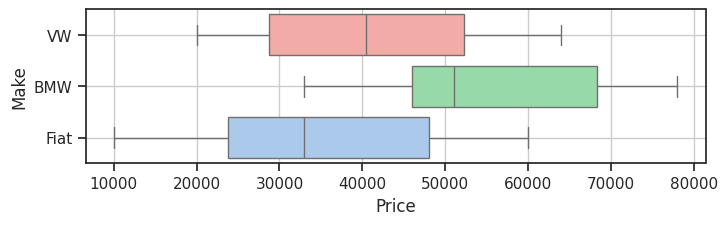

In [4]:
# Plot boxplot with groups
plt.figure(figsize=(8,2))
ax = sns.boxplot(x="Price",
                 y="Make",
                 palette=['r', 'g', 'b'],
                 data=df,
                 orient='h')
plt.grid()
plt.show()

## Analysis of variance (ANOVA)

In [5]:
# Create subsets (groups)
vw = df.loc[df['Make'] == 'VW']
bmw = df.loc[df['Make'] == 'BMW']
fiat = df.loc[df['Make'] == 'Fiat']

# Create ANOVA
fvalue, pvalue = stats.f_oneway(vw['Price'],
                                fiat['Price'], 
                                bmw['Price'])

# Print results
print('F-value:', fvalue.round(3), 'p-value', pvalue.round(4))

F-value: 9.791 p-value 0.0002


## Interpretation of result

<p> Because the p-value is lower than 0.05, the null hypothesis can be rejected, i.e. there is evidence that the used car prices of VW, BMW and Fiat differ. Note that, from the ANOVA, it is not clear which groups show differences of prices. For this a post-hoc test could be used (not part of the exercises).</p>

## Importing apartment data

In [6]:
# Read the data to a pandas data frame
df = pd.read_csv('apartments_data_enriched_cleaned.csv', 
                 sep=';', 
                 encoding='utf-8')[['web-scraper-order',
                                    'address_raw',
                                    'lat',
                                    'lon',
                                    'bfs_number',
                                    'bfs_name',
                                    'rooms', 
                                    'area', 
                                    'luxurious', 
                                    'price', 
                                    'price_per_m2',
                                    'pop_dens',
                                    'frg_pct',
                                    'mean_taxable_income',
                                    'dist_supermarket']]

# Get number of rows and columns
print(df.shape)

# Show first records
df.head(5)

(774, 15)


,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name,rooms,area,luxurious,price,price_per_m2,pop_dens,frg_pct,mean_taxable_income,dist_supermarket
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",47.252171,8.845797,118,Rüti (ZH),3.0,49,0,1441,29.41,1221.272366,24.841283,65362.04268,645.652248
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",47.252087,8.854919,118,Rüti (ZH),3.0,111,0,2600,23.42,1221.272366,24.841283,65362.04268,265.102153
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",47.253670,8.853993,118,Rüti (ZH),3.0,58,0,1490,25.69,1221.272366,24.841283,65362.04268,94.401821
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",47.259834,8.851705,118,Rüti (ZH),4.0,118,0,3240,27.46,1221.272366,24.841283,65362.04268,106.660970
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",47.266113,8.866872,118,Rüti (ZH),3.0,66,0,1450,21.97,1221.272366,24.841283,65362.04268,974.844209


## Create pivot table with mean price_per_m2 per room size

In [7]:
# Using pivot_table to reshape the data and calculate means 
pd.pivot_table(df[['rooms', 'price_per_m2']],
               index=['rooms'],
               values=['price_per_m2'],
               aggfunc=[np.mean, 'count'])

,mean,count
,price_per_m2,price_per_m2
rooms,,
1.0,47.140400,50
1.5,59.417576,33
2.0,40.757105,38
2.5,37.391631,141
3.0,28.677955,44
3.5,29.942956,203
4.0,29.646429,28
4.5,26.493436,163


## Create grouped boxplot (groups = rooms, values = prices_per_m2)

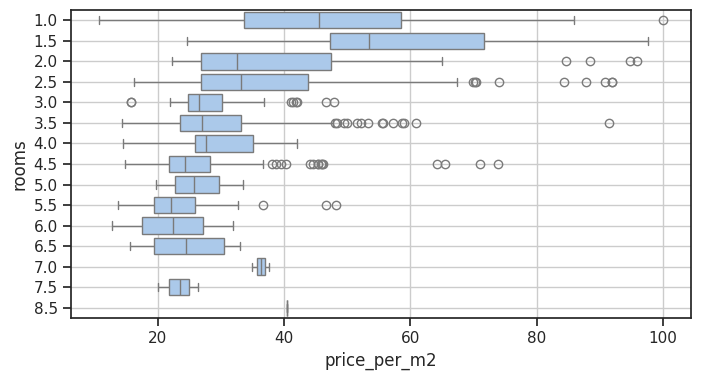

In [8]:
# Plot boxplot with groups
plt.figure(figsize=(8,4))
ax = sns.boxplot(x="price_per_m2",
                 y="rooms",
                 data=df,
                 orient='h')
plt.grid()
plt.show()

## ANOVA to compare the price_per_m2 per number of rooms (= groups)

In [9]:
# Create subsets (groups)
r2_5 = df.loc[df['rooms'] == 2.5]['price_per_m2']
r3_5 = df.loc[df['rooms'] == 3.5]['price_per_m2']
r4_5 = df.loc[df['rooms'] == 4.5]['price_per_m2']

# Create ANOVA
fvalue, pvalue = stats.f_oneway(r2_5, r3_5, r4_5)

# Print results
print('F-value:', fvalue.round(3), 'p-value', pvalue.round(4))

F-value: 34.26 p-value 0.0


## Interpretation of result

<p> Because the p-value is lower than 0.05, the null hypothesis can be rejected, i.e. there is evidence that the price per m2 differ between apartments with 2.5, 3.5 and 4.5 rooms. Note that, from the ANOVA, it is not clear which groups show price differences. For this a post-hoc test could be used (not part of the exercises).</p>

## ANOVA: Price per m² by Population Density Groups

### Creating Population Density Groups

We will create three groups based on population density:
- **Low population density:** pop_dens <= 600
- **Moderate population density:** 600 < pop_dens <= 1500
- **High population density:** pop_dens > 1500

In [10]:
# Create three subsets based on population density
low_density = df.loc[df['pop_dens'] <= 600]
moderate_density = df.loc[(df['pop_dens'] > 600) & (df['pop_dens'] <= 1500)]
high_density = df.loc[df['pop_dens'] > 1500]

print(f'Low population density (<=600): {len(low_density)} apartments')
print(f'Moderate population density (600-1500): {len(moderate_density)} apartments')
print(f'High population density (>1500): {len(high_density)} apartments')

Low population density (<=600): 105 apartments
Moderate population density (600-1500): 217 apartments
High population density (>1500): 452 apartments


In [11]:
# Create a categorical variable for population density groups
def classify_density(pop_dens):
    if pop_dens <= 600:
        return 'Low (<=600)'
    elif pop_dens <= 1500:
        return 'Moderate (600-1500)'
    else:
        return 'High (>1500)'

df['density_group'] = df['pop_dens'].apply(classify_density)
print(df['density_group'].value_counts())

density_group
High (>1500)           452
Moderate (600-1500)    217
Low (<=600)            105
Name: count, dtype: int64


### ANOVA Test 1: Price per m² across Population Density Groups

**Null Hypothesis (H0):** The mean prices per m² are equal across all three population density groups

**Alternative Hypothesis (H1):** At least one group has a different mean price per m²

**Significance level (α):** 0.05 (5%)

In [12]:
# Show mean price per m2 for each group
pd.pivot_table(df[['density_group', 'price_per_m2']],
               index=['density_group'],
               values=['price_per_m2'],
               aggfunc=[np.mean, 'count'])

,mean,count
,price_per_m2,price_per_m2
density_group,,
High (>1500),38.317301,452
Low (<=600),23.574190,105
Moderate (600-1500),25.978065,217


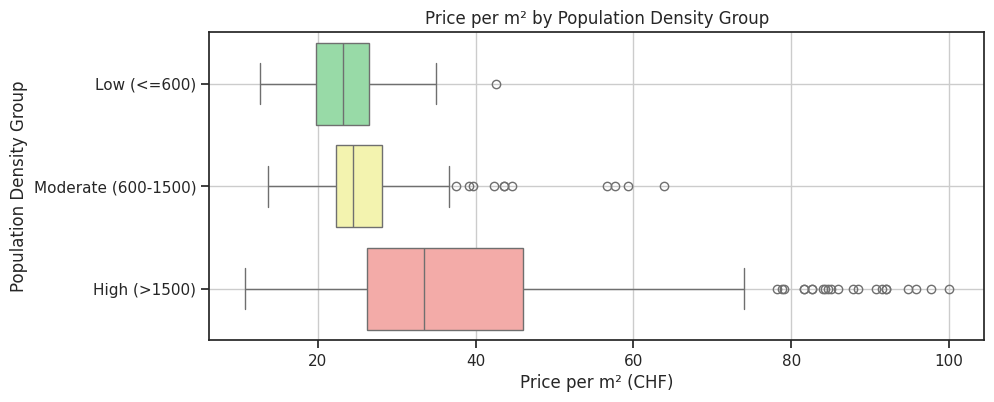

In [13]:
# Boxplot for price per m2 by density group
plt.figure(figsize=(10, 4))
ax = sns.boxplot(x='price_per_m2',
                 y='density_group',
                 data=df,
                 order=['Low (<=600)', 'Moderate (600-1500)', 'High (>1500)'],
                 palette=['g', 'y', 'r'],
                 orient='h')
plt.title('Price per m² by Population Density Group')
plt.xlabel('Price per m² (CHF)')
plt.ylabel('Population Density Group')
plt.grid()
plt.show()

In [14]:
# Perform one-way ANOVA on price per m2
fvalue_price, pvalue_price = stats.f_oneway(
    low_density['price_per_m2'],
    moderate_density['price_per_m2'],
    high_density['price_per_m2']
)

print('One-way ANOVA: Price per m² by Population Density')
print('=' * 50)
print(f'F-value: {fvalue_price:.3f}')
print(f'p-value: {pvalue_price:.6f}')
print('=' * 50)

One-way ANOVA: Price per m² by Population Density
F-value: 91.272
p-value: 0.000000


### Interpretation: Price per m²

Since the p-value is less than 0.05, we **reject the null hypothesis**. There is statistically significant evidence that the prices per m² differ across municipalities with different population densities. Generally, higher population density areas (urban centers) tend to have higher rental prices per m².

### ANOVA Test 2: Apartment Area across Population Density Groups

**Null Hypothesis (H0):** The mean apartment areas are equal across all three population density groups

**Alternative Hypothesis (H1):** At least one group has a different mean apartment area

**Significance level (α):** 0.05 (5%)

In [15]:
# Show mean area for each group
pd.pivot_table(df[['density_group', 'area']],
               index=['density_group'],
               values=['area'],
               aggfunc=[np.mean, 'count'])

,mean,count
,area,area
density_group,,
High (>1500),82.013274,452
Low (<=600),112.780952,105
Moderate (600-1500),91.686636,217


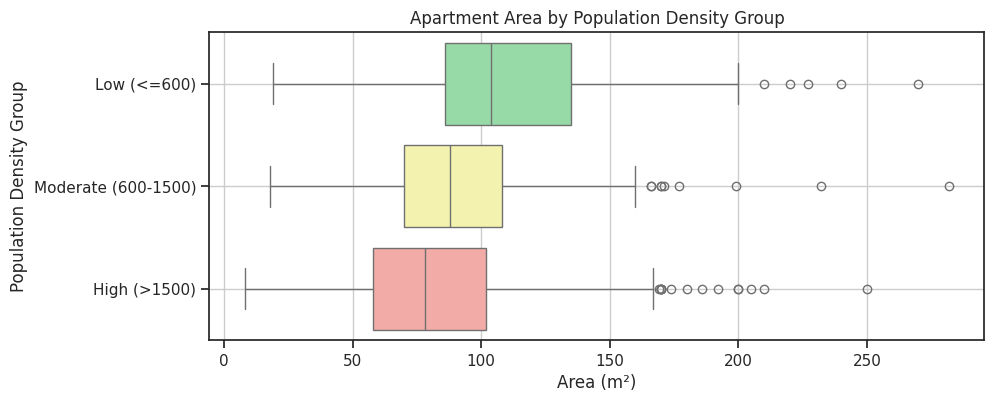

In [16]:
# Boxplot for area by density group
plt.figure(figsize=(10, 4))
ax = sns.boxplot(x='area',
                 y='density_group',
                 data=df,
                 order=['Low (<=600)', 'Moderate (600-1500)', 'High (>1500)'],
                 palette=['g', 'y', 'r'],
                 orient='h')
plt.title('Apartment Area by Population Density Group')
plt.xlabel('Area (m²)')
plt.ylabel('Population Density Group')
plt.grid()
plt.show()

In [17]:
# Perform one-way ANOVA on area
fvalue_area, pvalue_area = stats.f_oneway(
    low_density['area'],
    moderate_density['area'],
    high_density['area']
)

print('One-way ANOVA: Apartment Area by Population Density')
print('=' * 50)
print(f'F-value: {fvalue_area:.3f}')
print(f'p-value: {pvalue_area:.6f}')
print('=' * 50)

One-way ANOVA: Apartment Area by Population Density
F-value: 28.478
p-value: 0.000000


### Interpretation: Apartment Area

Based on the p-value compared to the significance level of 0.05, we can determine whether there is a significant difference in apartment areas across population density groups. If p-value < 0.05, we reject the null hypothesis.

### ANOVA Test 3: Number of Rooms across Population Density Groups

**Null Hypothesis (H0):** The mean number of rooms is equal across all three population density groups

**Alternative Hypothesis (H1):** At least one group has a different mean number of rooms

**Significance level (α):** 0.05 (5%)

In [18]:
# Show mean number of rooms for each group
pd.pivot_table(df[['density_group', 'rooms']],
               index=['density_group'],
               values=['rooms'],
               aggfunc=[np.mean, 'count'])

,mean,count
,rooms,rooms
density_group,,
High (>1500),3.112832,452
Low (<=600),4.214286,105
Moderate (600-1500),3.668203,217


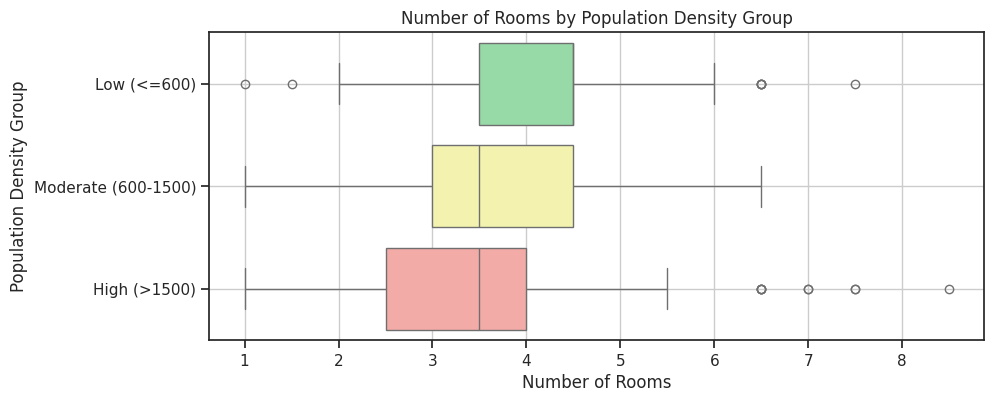

In [19]:
# Boxplot for rooms by density group
plt.figure(figsize=(10, 4))
ax = sns.boxplot(x='rooms',
                 y='density_group',
                 data=df,
                 order=['Low (<=600)', 'Moderate (600-1500)', 'High (>1500)'],
                 palette=['g', 'y', 'r'],
                 orient='h')
plt.title('Number of Rooms by Population Density Group')
plt.xlabel('Number of Rooms')
plt.ylabel('Population Density Group')
plt.grid()
plt.show()

In [20]:
# Perform one-way ANOVA on number of rooms
fvalue_rooms, pvalue_rooms = stats.f_oneway(
    low_density['rooms'],
    moderate_density['rooms'],
    high_density['rooms']
)

print('One-way ANOVA: Number of Rooms by Population Density')
print('=' * 50)
print(f'F-value: {fvalue_rooms:.3f}')
print(f'p-value: {pvalue_rooms:.6f}')
print('=' * 50)

One-way ANOVA: Number of Rooms by Population Density
F-value: 41.043
p-value: 0.000000


### Interpretation: Number of Rooms

Based on the p-value compared to the significance level of 0.05, we can determine whether there is a significant difference in the number of rooms across population density groups. In urban areas with high population density, apartments typically have fewer rooms due to space constraints.

## Summary of ANOVA Results

The ANOVA tests reveal how population density affects various aspects of rental apartments:

1. **Price per m²**: Higher population density areas typically have higher prices per m², reflecting the urban premium in housing costs.
2. **Area**: The relationship between population density and apartment area depends on the specific market characteristics.
3. **Number of Rooms**: Urban areas with high population density tend to have apartments with fewer rooms due to space constraints and higher costs.

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [21]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.11.0-1018-azure
Datetime: 2025-12-02 18:22:22
Python Version: 3.12.3
-----------------------------------
